# Step 2: Data Quality Checks
- This notebook imports data generated by step1 and produces distributions for each PR metric along with a description


## 1. Setup Notebook Inputs
- path is where the data assets will be read in from
- Analysis file is the file created in step 1


In [7]:
path = '/project_data/data_asset/'
analysis_file = 'pipeline_op_analysis_04012020_06302020.csv'

## Import Libraries

In [8]:
import pandas as pd
pd.set_option('display.max_columns', None)

from scipy.stats import zscore
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Read in dataset

In [9]:
data_df = pd.read_csv(path + '/' + analysis_file)

data_df.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,32,80,4119.0,2020-06-29,2020-04-01,105691,90,2.5,128.718750,0.888889,45.766667,0.060000,0.03125,5,0.0,0.0,0.0,0.1125,0.32,0,0,0.0,0.0,6.439075,0.0,0.0,0.0,0.03125,0.0,0.21875,0.0,0.03125
1,4,4,266.0,2020-06-19,2020-04-29,105693,52,1.0,66.500000,0.076923,5.115385,0.061224,0.00000,0,0.0,0.0,0.0,0.2500,0.00,0,0,0.0,0.0,1.758067,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.00000
2,1,1,30.0,2020-04-30,2020-04-30,105699,1,1.0,30.000000,1.000000,30.000000,0.000000,0.00000,0,0.0,0.0,0.0,0.0000,0.00,0,0,0.0,0.0,13.271845,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.00000
3,5,9,215.0,2020-06-10,2020-05-18,105700,24,1.8,43.000000,0.375000,8.958333,0.108696,0.00000,3,0.0,0.0,0.0,1.0000,0.00,0,0,0.0,0.0,6.675857,0.0,0.0,0.0,0.00000,0.0,0.40000,0.0,0.00000
4,3,6,340.0,2020-06-29,2020-04-04,105707,87,2.0,113.333333,0.068966,3.908046,0.032258,0.00000,0,0.0,0.0,0.0,0.0000,0.00,0,0,0.0,0.0,17.707574,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.00000


## How many providers are in the dataset?

In [10]:
num_providers = data_df['PRSCRB_PROV_LOC_ID'].drop_duplicates().count()

print('There are {} providers in the dataset'.format(num_providers))

There are 12563 providers in the dataset


## Get summary statistics

In [11]:
summary_df = data_df.describe()

summary_df

,Member Count,Count Script,Sum Dispensed Quantity,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
count,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.0,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000,12563.000000
mean,8.820505,17.965932,914.474605,119763.206877,51.611876,1.633375,70.523448,0.447459,17.390591,0.149800,0.041119,0.338932,0.000069,0.000676,0.024036,0.363906,0.093724,0.0,0.000716,0.001158,0.020852,23.342450,0.029133,0.002203,0.049881,0.001405,0.000023,0.197767,0.015711,0.001452
std,16.207298,47.535805,3301.499283,44333.787691,33.295725,0.905815,84.609503,0.612809,41.433801,0.202445,0.165114,1.920752,0.000616,0.018372,0.096628,0.372098,0.170872,0.0,0.026757,0.024809,0.086616,99.603292,0.149229,0.030185,0.141813,0.021360,0.001481,0.279969,0.077166,0.019878
min,1.000000,1.000000,1.000000,12.000000,1.000000,1.000000,0.750000,0.022222,0.030303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,45.000000,107525.000000,18.000000,1.000000,17.142857,0.100000,2.411765,0.017857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,5.932823,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,5.000000,150.000000,122652.000000,61.000000,1.260870,41.444444,0.195402,6.446809,0.075235,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.0,0.000000,0.000000,0.000000,10.597428,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
75%,9.000000,15.000000,607.500000,150428.500000,83.000000,2.000000,90.781579,0.800000,17.491573,0.194444,0.000000,0.000000,0.000000,0.000000,0.000000,0.666667,0.140000,0.0,0.000000,0.000000,0.000000,21.428331,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000
max,292.000000,1429.000000,125456.500000,182795.000000,91.000000,15.000000,1440.000000,15.703297,1378.642857,1.000000,1.000000,71.000000,0.034483,1.000000,1.000000,1.000000,0.810000,0.0,1.000000,1.000000,1.000000,7184.205009,1.000000,1.000000,1.000000,1.000000,0.142857,1.000000,1.000000,1.000000


# Distributions

## PR1
- Despensed quantity per member

,PR1
count,12563.000000
mean,70.523448
std,84.609503
min,0.750000
25%,17.142857
50%,41.444444
75%,90.781579
max,1440.000000


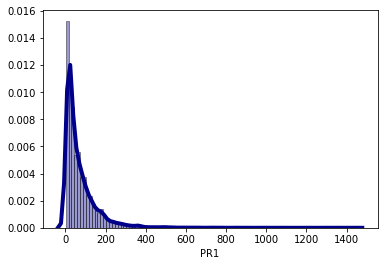

In [12]:
sns.distplot(data_df.PR1, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR1.describe())

## PR2
 - Quantity of presciptions per member

,PR2
count,12563.000000
mean,1.633375
std,0.905815
min,1.000000
25%,1.000000
50%,1.260870
75%,2.000000
max,15.000000


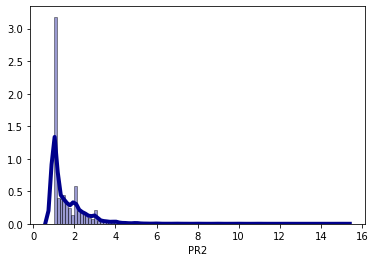

In [13]:
sns.distplot(data_df.PR2, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR2.describe())

## PR3
- Quantity of pills dispensed per day

,PR3
count,12563.000000
mean,17.390591
std,41.433801
min,0.030303
25%,2.411765
50%,6.446809
75%,17.491573
max,1378.642857


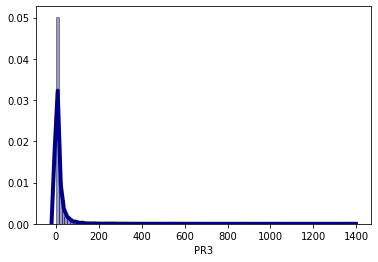

In [14]:
sns.distplot(data_df.PR3, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR3.describe())

## PR4
- Number of RX per day

,PR4
count,12563.000000
mean,0.447459
std,0.612809
min,0.022222
25%,0.100000
50%,0.195402
75%,0.800000
max,15.703297


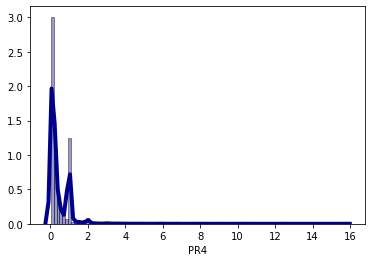

In [15]:
sns.distplot(data_df.PR4, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR4.describe())

## PR5
- Percentage of claims for schedule 2 drugs

,PR5
count,12563.000000
mean,0.149800
std,0.202445
min,0.000000
25%,0.017857
50%,0.075235
75%,0.194444
max,1.000000


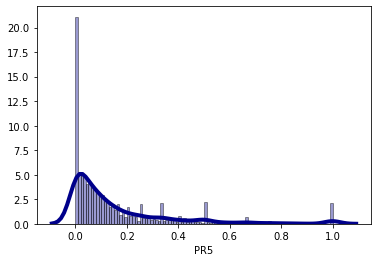

In [16]:
sns.distplot(data_df.PR5, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR5.describe())

# PR6
- Percentage of member with controled substances (CS) RX and no cancer or hospice diag

,PR6
count,12563.000000
mean,0.041119
std,0.165114
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


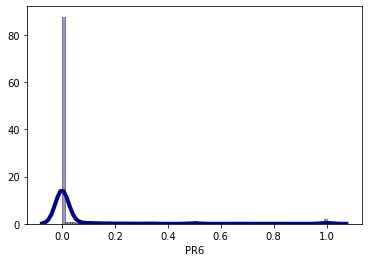

In [17]:
sns.distplot(data_df.PR6, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR6.describe())

## PR7
- Number of Members with upward MME trending (positive reg coefficent)

,PR7
count,12563.000000
mean,0.338932
std,1.920752
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,71.000000


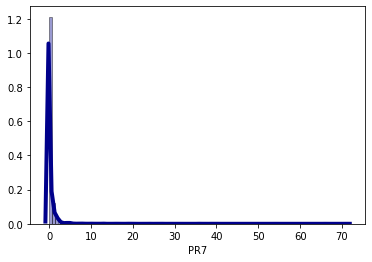

In [18]:
sns.distplot(data_df.PR7, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR7.describe())

## PR8
- Percentage of members with death related to opoids

,PR8
count,12563.000000
mean,0.000069
std,0.000616
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.034483


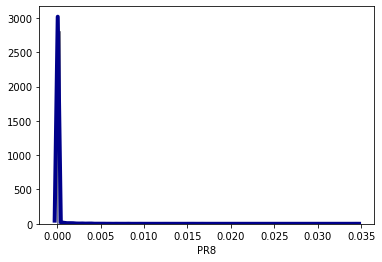

In [19]:
sns.distplot(data_df.PR8, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR8.describe())

## PR9
- Percentage of members with morbidity events related to opoids

,PR9
count,12563.000000
mean,0.000676
std,0.018372
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


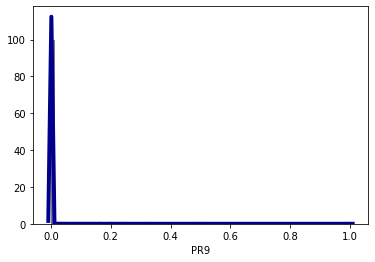

In [20]:
sns.distplot(data_df.PR9, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR9.describe())

## PR10
- Percentage of members with a Trinity Rx (members can appear under multiple providers)

,PR10
count,12563.000000
mean,0.024036
std,0.096628
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


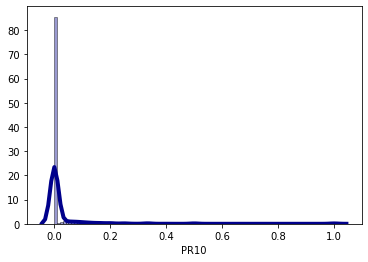

In [21]:
sns.distplot(data_df.PR10, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR10.describe())

## PR11
- Percentage of members with an E/M code from Rx provider

,PR11
count,12563.000000
mean,0.363906
std,0.372098
min,0.000000
25%,0.000000
50%,0.250000
75%,0.666667
max,1.000000


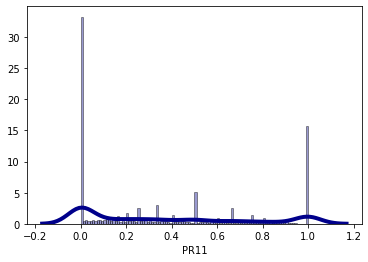

In [22]:
sns.distplot(data_df.PR11, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR11.describe())

## PR12
- High count of members with SUD addresses? - carved out

In [23]:
# Skipped

## PR13
- Percentage of denied claims

,PR13
count,12563.000000
mean,0.093724
std,0.170872
min,0.000000
25%,0.000000
50%,0.000000
75%,0.140000
max,0.810000


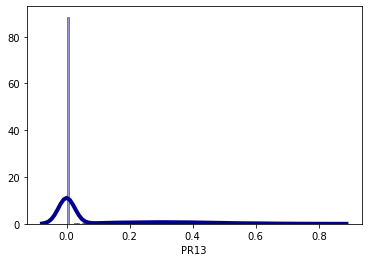

In [24]:
sns.distplot(data_df.PR13, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR13.describe())

## PR14
- High incidence of prior auth (PA) or place of service (POS) override? - carved out.  Bad data

In [25]:
# Skipped

## PR15
- Does the Rx prov own a portion of the pharm where it was filled (dichotomous)

/opt/conda/envs/Python-3.6-WMLCE/lib/python3.6/site-packages/seaborn/distributions.py:288: UserWarning: Data must have variance to compute a kernel density estimate.
  warnings.warn(msg, UserWarning)


,PR15
count,12563.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


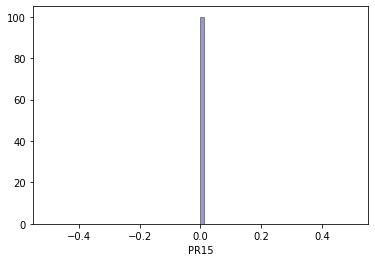

In [26]:
sns.distplot(data_df.PR15, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR15.describe())

## PR16
- Referring relationship? - carved out for relevance

In [27]:
# Skipped

## PR17
- High count of members with lock-in history? - carved out for data availability

In [28]:
# Skipped

## PR18
- Does the Rx provider's NPI appear on the fed matching lists (dichotomous)

,PR18
count,12563.000000
mean,0.000716
std,0.026757
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


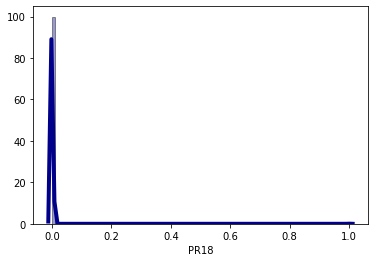

In [29]:
sns.distplot(data_df.PR18, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR18.describe())

## PR19
- Percentage of members with Suboxone and opioid Rx within a week or eachother

,PR19
count,12563.000000
mean,0.001158
std,0.024809
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


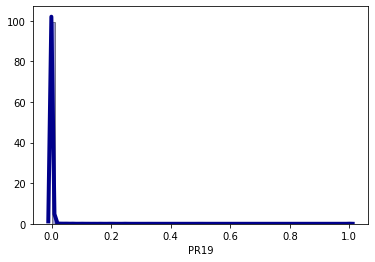

In [30]:
sns.distplot(data_df.PR19, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR19.describe())

## PR20
- Suboxone exceeding 16 mg/day dosing? - carved out

In [31]:
# Skipped

## PR21
- Percentage of members with atypicals and opoids within a week

,PR21
count,12563.000000
mean,0.020852
std,0.086616
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


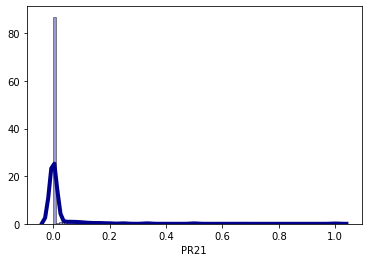

In [32]:
sns.distplot(data_df.PR21, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR21.describe())

## PR22
- Average member driving distance

,PR22
count,12563.000000
mean,23.342450
std,99.603292
min,0.000000
25%,5.932823
50%,10.597428
75%,21.428331
max,7184.205009


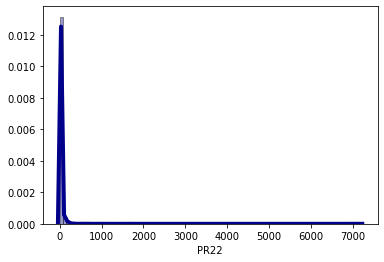

In [33]:
sns.distplot(data_df.PR22, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR22.describe())

## PR23
- Percentage of members under 18 with Opioid Rx

,PR23
count,12563.000000
mean,0.029133
std,0.149229
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


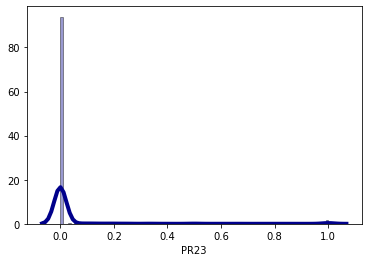

In [34]:
sns.distplot(data_df.PR23, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR23.describe())

## PR24
- Percentage of members with Subutex Rx

,PR24
count,12563.000000
mean,0.002203
std,0.030185
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


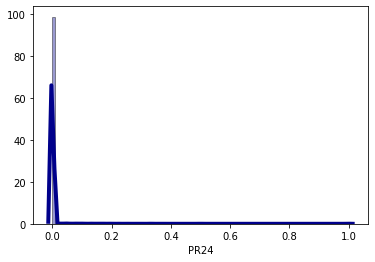

In [35]:
sns.distplot(data_df.PR24 , hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR24.describe())

# sns.distplot(data_df.PR24 * data_df['Member Count'] , hist=True, kde=True, 
#              bins=100, color = 'darkblue', 
#              hist_kws={'edgecolor':'black'},
#              kde_kws={'linewidth': 4})

# pd.DataFrame((data_df.PR24 * data_df['Member Count']).describe())

## PR25
- Percentage of members with Gabapentin Rx

,PR25
count,12563.000000
mean,0.049881
std,0.141813
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


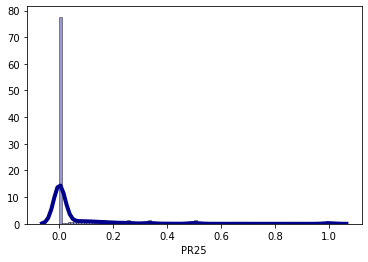

In [36]:
sns.distplot(data_df.PR25, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR25.describe())

## PR26
- Percentage of members with Benzos and Suboxone Rx within a week

,PR26
count,12563.000000
mean,0.001405
std,0.021360
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


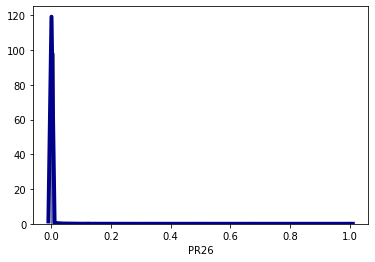

In [37]:
sns.distplot(data_df.PR26, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR26.describe())

## PR27
- Percentage of members with Opioid and Naloxone within a week

,PR27
count,12563.000000
mean,0.000023
std,0.001481
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.142857


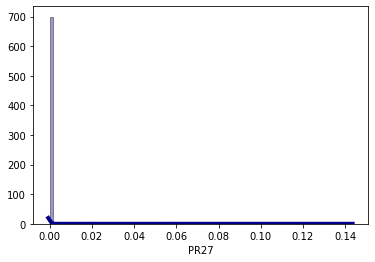

In [38]:
sns.distplot(data_df.PR27, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR27.describe())

## PR28
- Percentage of members with SUD diags

,PR28
count,12563.000000
mean,0.197767
std,0.279969
min,0.000000
25%,0.000000
50%,0.052632
75%,0.333333
max,1.000000


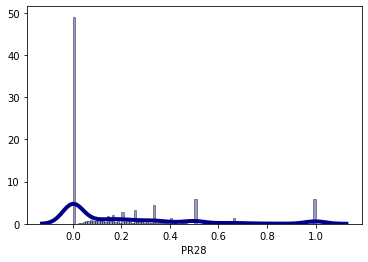

In [39]:
sns.distplot(data_df.PR28, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR28.describe())

## PR29
- Percentage of claims filed during major weather events

,PR29
count,12563.000000
mean,0.015711
std,0.077166
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


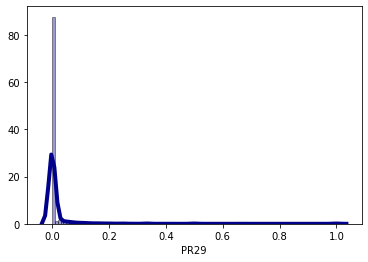

In [40]:
sns.distplot(data_df.PR29, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR29.describe())

## PR30
- Percentage of members with Extended Release Long Acting Opoids when opioid-naive

,PR30
count,12563.000000
mean,0.001452
std,0.019878
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


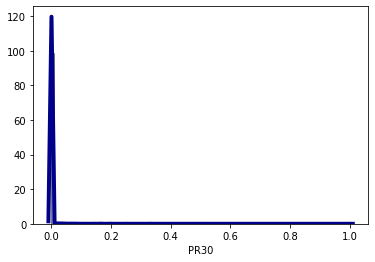

In [41]:
sns.distplot(data_df.PR30, hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(data_df.PR30.describe())